<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 6 Day 1: Sprint 1 Kickoff & Baseline Model
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 1 Learning Objectives:</b>
-  <b>Sprint 1 Planning:</b> Confirm the Sprint 1 goal, select initial backlog tasks (dataset finalization, EDA, and baseline modeling), and commit to the Definition of Done.
-  <b>Neural Network Architecture Foundations:</b> Explain the single neuron as a weighted sum, bias, and activation ($z = \mathbf{w} \cdot \mathbf{x} + b$, $\text{output} = \text{activation}(z)$) and describe the roles of input, hidden, and output layers.
-  <b>Exploratory Data Analysis:</b> Ingest the Cardiac Patient Monitoring dataset (<code>heart.csv</code>), evaluate clinical feature distributions, and inspect target class balance.
-  <b>Leak-Free Preprocessing Pipeline:</b> Construct a Scikit-Learn <code>ColumnTransformer</code> with <code>StandardScaler</code> for numeric features and <code>OneHotEncoder</code> for categorical attributes.
-  <b>Baseline Model & Benchmark Establishment:</b> Train a classical Logistic Regression model, evaluate test metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC), and record the benchmark score every later neural network model must beat.

</blockquote>


## <span style="color: #309c42ff">1.1 Environment Setup & Library Imports</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core numerical and visualization libraries alongside Scikit-Learn modules for stratified data splitting, column transformations, feature scaling, one-hot encoding, and classification metrics.

</blockquote>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## <span style="color: #309c42ff">1.2 Dataset Loading & Data Integrity Inspection</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We load the Cardiac Patient Monitoring dataset (<code>heart.csv</code>) containing 918 patient observations across 11 clinical features. We inspect feature data types, confirm zero missing records, and assess the target distribution for <code>HeartDisease</code> (0 = Normal, 1 = Heart Disease present).

</blockquote>


In [2]:
data_path = "../../Projects/cardiac_monitoring_project/Data/heart.csv"
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()
display(df.head())


Dataset Shape: 918 rows, 12 columns
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print(f"RestingBP == 0 count: {(df['RestingBP'] == 0).sum()}")
print(f"Cholesterol == 0 count: {(df['Cholesterol'] == 0).sum()}")

df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

print("\nMissing values after replacing impossible 0s with NaN:")
print(df.isnull().sum())


RestingBP == 0 count: 1
Cholesterol == 0 count: 172

Missing values after replacing impossible 0s with NaN:
Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64


## <span style="color: #309c42ff">1.3 Exploratory Data Analysis & Clinical Observations</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We visualize feature distributions across diagnostic classes. The cohort exhibits balanced diagnostic representation (~55.3% positive cases), an age distribution showing higher risk in older cohorts, lower maximum exercise heart rate (<code>MaxHR</code>) among cardiac patients, and strong risk correlation with flat/downsloping ST segments.

</blockquote>


In [4]:
print("Missing values per column:\n", df.isnull().sum())
print("\nTarget Class Distribution ('HeartDisease'):")
print(df['HeartDisease'].value_counts(normalize=True))


Missing values per column:
 Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

Target Class Distribution ('HeartDisease'):
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


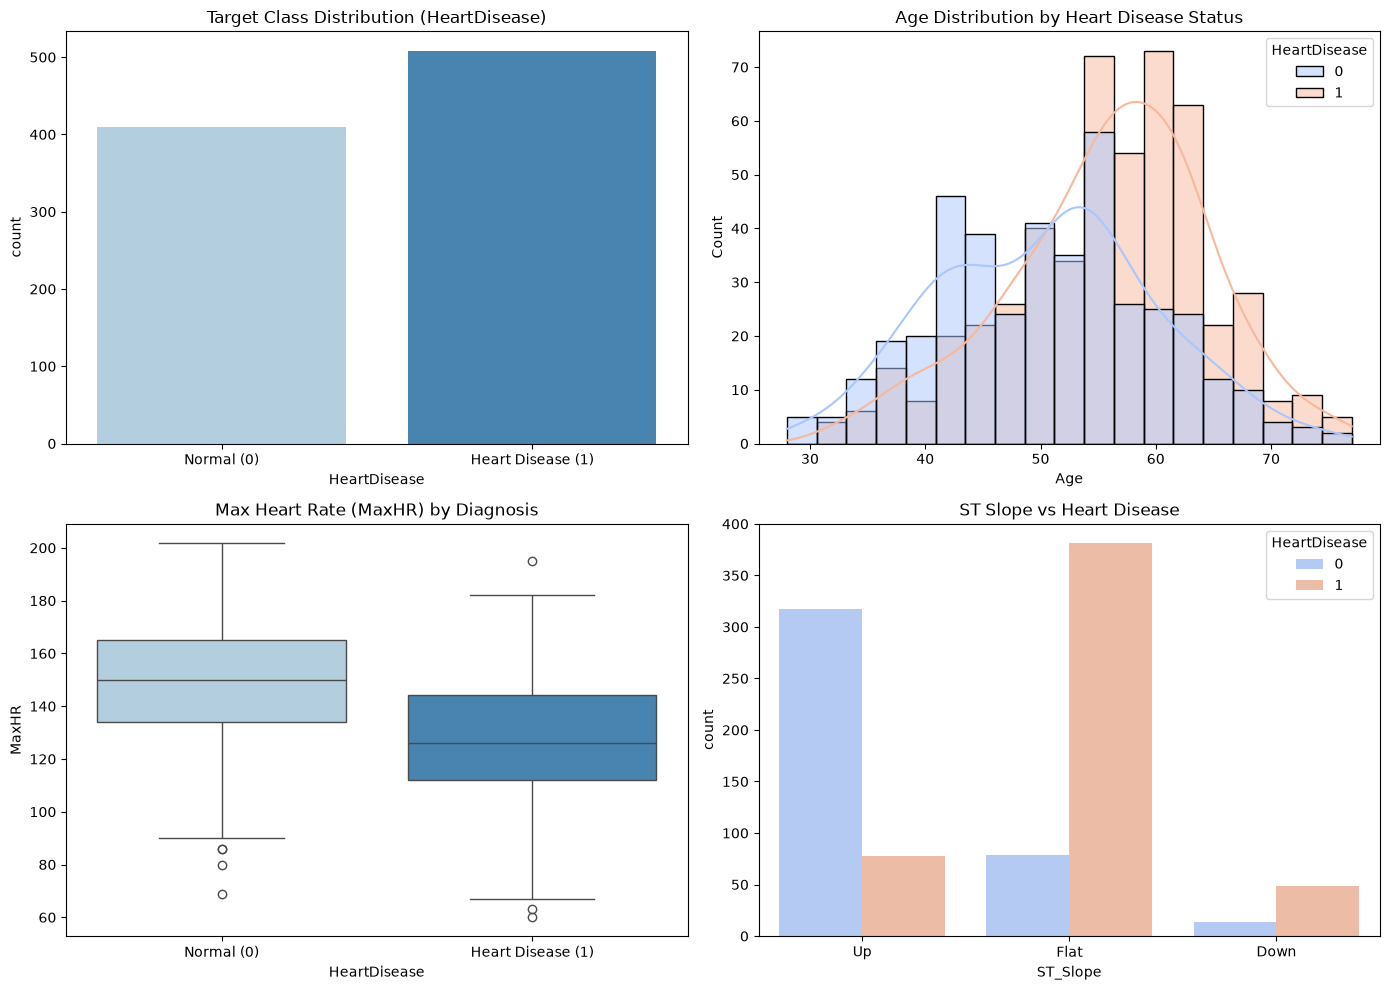

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='HeartDisease', hue='HeartDisease', palette='Blues', legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Target Class Distribution (HeartDisease)")
axes[0, 0].set_xticks([0, 1], labels=["Normal (0)", "Heart Disease (1)"])

sns.histplot(data=df, x='Age', hue='HeartDisease', kde=True, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title("Age Distribution by Heart Disease Status")

sns.boxplot(data=df, x='HeartDisease', y='MaxHR', hue='HeartDisease', palette='Blues', legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Max Heart Rate (MaxHR) by Diagnosis")
axes[1, 0].set_xticks([0, 1], labels=["Normal (0)", "Heart Disease (1)"])

sns.countplot(data=df, x='ST_Slope', hue='HeartDisease', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title("ST Slope vs Heart Disease")

plt.tight_layout()
plt.show()


## <span style="color: #309c42ff">1.4 Stratified Train-Test Splitting & Leak-Free Preprocessing</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

To eliminate data leakage, we partition the dataset into an 80% training set and a 20% test set using stratified sampling (<code>stratify=y</code>). We assemble a <code>ColumnTransformer</code> applying <code>StandardScaler</code> to numeric features (<code>Age</code>, <code>RestingBP</code>, <code>Cholesterol</code>, <code>MaxHR</code>, <code>Oldpeak</code>) and <code>OneHotEncoder(drop='first')</code> to categorical features.

</blockquote>


In [6]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Training set: 734 samples
Test set:     184 samples


In [7]:
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## <span style="color: #309c42ff">1.5 Baseline Model Training (Logistic Regression)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We encapsulate the preprocessor and a <code>LogisticRegression</code> classifier into a Scikit-Learn <code>Pipeline</code>. Fitting the pipeline exclusively on the training set ensures all scalers and encoders learn parameters without test set leakage.

</blockquote>


In [8]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_pipeline.fit(X_train, y_train)

y_pred = baseline_pipeline.predict(X_test)
y_prob = baseline_pipeline.predict_proba(X_test)[:, 1]


## <span style="color: #309c42ff">1.6 Model Evaluation & Diagnostic Visualizations</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We evaluate the baseline model on the unseen 20% test split, generating a Confusion Matrix and ROC Curve to measure diagnostic sensitivity, precision, F1-Score, and overall discriminative capacity (ROC-AUC).

</blockquote>


In [9]:
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

display(pd.DataFrame(baseline_metrics, index=["Logistic Regression Baseline (Imputed)"]).T)

,Logistic Regression Baseline (Imputed)
Accuracy,0.885870
Precision,0.885714
Recall,0.911765
F1-Score,0.898551
ROC-AUC,0.932927


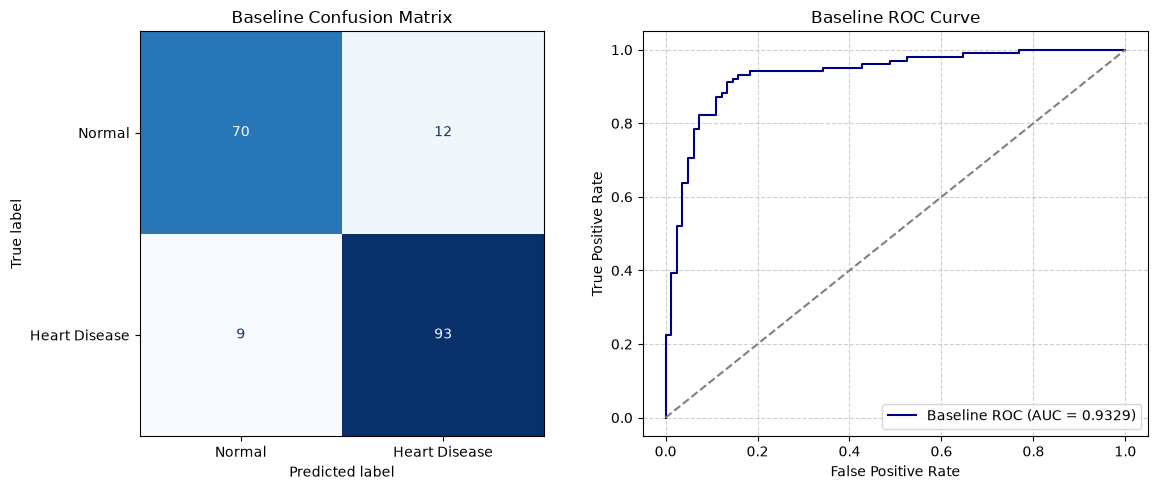

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Baseline Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"Baseline ROC (AUC = {baseline_metrics['ROC-AUC']:.4f})", color='navy')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Baseline ROC Curve")
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## <span style="color: #309c42ff">1.7 Sprint 1 Baseline Benchmark Target</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Sprint 1 Baseline Acceptance Criteria:</b><br>
A neural network's score is meaningless without a baseline. The performance metrics recorded below define the minimum acceptable standard for Sprint 1. Any neural network architecture built on Day 4 and tuned on Day 5 must exceed this baseline F1-Score and ROC-AUC under identical evaluation conditions to earn its place in the clinical pipeline.

</blockquote>


| Metric | Baseline Score (Logistic Regression with Imputation) | Benchmark Interpretation |
| :--- | :--- | :--- |
| **Accuracy** | 0.8859 | 88.59% overall correct diagnostic classifications |
| **Precision** | 0.8857 | 88.57% of predicted cardiac cases are true positive |
| **Recall (Sensitivity)** | 0.9118 | 91.18% of actual heart disease patients detected |
| **F1-Score** | 0.8986 | Harmonic balance between clinical precision and recall |
| **ROC-AUC** | 0.9329 | High discriminative power across diagnostic thresholds |

**Sprint 1 Acceptance Target:**
Every deep learning architecture developed on Day 4 and tuned on Day 5 must exceed this baseline **F1-Score (0.8986)** and **ROC-AUC (0.9329)** under the exact same data split.
